In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    roc_auc_score,
    classification_report
)
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from keras.datasets import mnist
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


# ¿Qué es el Machine Learning?

El Machine Learning es una rama de la Inteligencia Artificial en los cuales un modelo aprende de datos.

![alt text](https://storage.googleapis.com/media-newsinitiative/images/2.2_jS8DI9n.original.png)


# Aprendizaje supervisado y no supervisado

## Aprendizaje supervisado

Se tiene un set de datos y se sabe cómo debería ser la salida del modelo.

- **Clasificación:** Regresión Logística, Árbol de decisión, Random Forest, XGBoost, KNN, SVM, Redes Neuronales.
- **Regresión:** Regresión lineal, Arboles de decisión, Random Forest, XGBoost, SVR, Redes Neuronales, forecasting.

## Aprendizaje no supervisado

Se tiene un set de datos pero sin las etiquetas (estructura de la data).
  
- **Clustering:** K-Means, DBScan, cluster jerárquico.
- **Otros no supervisado:** PCA, Autoencoders.

![alt text](https://upload.wikimedia.org/wikipedia/commons/4/4d/Supervised_and_unsupervised_learning.png)




# Métricas

## Regresión

Recordemos que el objetivo de un modelo de regresión es predecir un valor numérico continuo.

Para un modelo de regresión tenemos el valor target $y$, es decir, los valores reales a predecir, y los valores predichos $\widehat{y}$. El desempeño de un modelo es estimado por medio de medir la **similaridad** de estos valores en un conjunto de datos.

La idea con una métrica de regresión es determinar que tan bueno es un modelo de regresión.

Algunos ejemplos de métricas de regresión se muestran a continuación.

### Mean Absolute Error (MAE)

$$ MAE = \frac{1}{n} \sum_{i=1}^{n} \left|y_i - \widehat{y}_i\right| $$

(Menor valor es mejor)

In [ ]:
true_values = [2.5, 3.7, 1.8, 4.0, 5.2]
predicted_values = [2.1, 3.9, 1.7, 3.8, 5.0]

mae = mean_absolute_error(true_values, predicted_values)
print(f'Mean Absolute Error: {mae:.4f}')

Mean Absolute Error: 0.2200


### Mean Squared Error (MSE)

$$ MSE = \frac{1}{n} \sum_{i=1}^{n} \left(y_i - \widehat{y}_i\right)^2 $$

(Menor valor es mejor)

In [ ]:
true_values = [2.5, 3.7, 1.8, 4.0, 5.2]
predicted_values = [2.1, 3.9, 1.7, 3.8, 5.0]

mse = mean_squared_error(true_values, predicted_values)
rmse = np.sqrt(mse)
print(f'Mean Squared Error: {mse:.4f}')
print(f'Root Mean Squared Error: {rmse:.4f}')

Mean Squared Error: 0.0580
Root Mean Squared Error: 0.2408


### R-squared $\left(R^2\right)$

$$ R^2 = 1 - \frac{SS_{res}}{SS_{tot}} $$

$SS_{res} = \sum_{i=1}^{n} (y_i - \widehat{y}_i)^2$

$SS_{tot} = \sum_{i=1}^{n} (y_i - \bar{y})^2$

$\bar{y} = \frac{1}{n} \sum_{i=1}^{n} y_i$

En el mejor caso el modelo tendrá un $R^2$ de 1

In [ ]:
true_values = [2.5, 3.7, 1.8, 4.0, 5.2]
predicted_values = [2.1, 3.9, 1.7, 3.8, 5.0]

r2 = r2_score(true_values, predicted_values)
print(f'R-squared Score: {r2:.4f}')

R-squared Score: 0.9589


### Mean Absolute Percentage Error (MAPE)

$$ MAPE = 100 \frac{1}{n} \sum_{i=1}^{n} \left|\frac{y_i - \widehat{y}_i}{y_i}\right| $$

(Menor valor es mejor)


In [ ]:
true_prices = np.array([250000, 300000, 200000, 400000, 350000])
predicted_prices = np.array([240000, 310000, 210000, 380000, 340000])

# Calculate RMSE
mape = mean_absolute_percentage_error(true_prices, predicted_prices) * 100

print(f'Mean Absolute Percentage Error (MAPE): {mape:.4f}')

Mean Absolute Percentage Error (MAPE): 4.0381


### Ejemplo de métricas de regresión usando un set de datos

In [ ]:
# Load the California Housing Prices dataset
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
# Split the data into features (X) and target variable (y)
X = df.drop(columns=['target'])
y = df['target']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

In [ ]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r_squared = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

# Print the evaluation metrics
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'R-squared (R^2): {r_squared:.4f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.4f}')

Mean Absolute Error (MAE): 0.5332
Mean Squared Error (MSE): 0.5559
Root Mean Squared Error (RMSE): 0.7456
R-squared (R^2): 0.5758
Mean Absolute Percentage Error (MAPE): 31.9522


**¿Cómo se pueden interpretar estos resultados?**

## Clasificación

Son un tipo de problema supervisado en el cual un modelo es entrenado para predecir la clase o categoría de un set de datos, basado en sus propiedades.

### Matriz de confusión

- True Positives (TP)
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)

|                         | Pred. Negative (0) | Pred. Positive (1) |
|-------------------------|:------------------:|:------------------:|
| **Actual Negative (0)** | TN                 | FP                 |
| **Actual Positive (1)** | FN                 | TP                 |

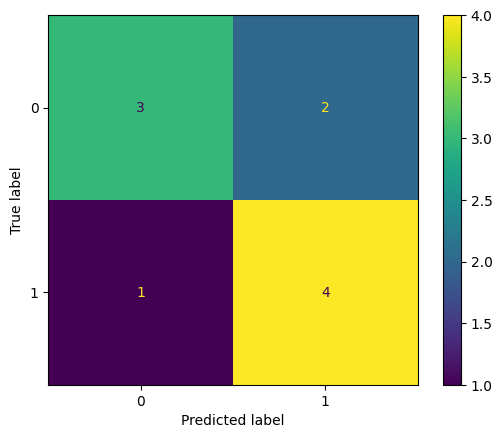

In [ ]:
# True labels
y_true = [0, 1, 1, 0, 1, 0, 0, 1, 1, 0]
# Predicted labels
y_pred = [0, 1, 0, 0, 1, 1, 0, 1, 1, 1]

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

cm_display.plot();

### Accuracy

Este mide la proporción de valores correctamente predichos tanto positivos como negativos.

$$\text{Accuracy} = \frac{TP+TN}{TP+TN+FP+FN}$$

**Ventajas:** Facilmente interpretable.

**Desventajas:** Puede ser una métrica engañosa cuando tratamos con data desbalanceada, es decir, hay una clase significativamente mayoritaria sobre otra.

In [ ]:
# True labels
y_true = [0, 1, 1, 0, 1, 0, 0, 1, 1, 0]
# Predicted labels
y_pred = [0, 1, 0, 0, 1, 1, 0, 1, 1, 1]

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

print(f'Accuracy: {accuracy:0.2f}')

Accuracy: 0.70


### Precision

Mide la capacidad del modelo de predecir casos positivos correctamente, haciendolo valioso en casos en donde un falso negativo puede ser altamente no deseado.

$$\text{Precision} = \frac{TP}{TP+FP}$$

Casos donde la presición puede ser importante:
- **Diagnóstico médico:** Falsos negativos pueden llevar a estrés o exámenes posteriores innecesarios.
- **Detección de Spam:** Predecir un correo legítimo como spam puede llevar a perder mensajes importantes, dañando la experiencia de usuario.


In [ ]:
# True labels
y_true = [0, 1, 1, 0, 1, 0, 0, 1, 1, 0]
# Predicted labels
y_pred = [0, 1, 0, 0, 1, 1, 0, 1, 1, 1]

# Precision
precision = precision_score(y_true, y_pred)

print(f'Precision: {precision:0.2f}')

Precision: 0.67


### Recall

Es importante para evaluar la capacidad del modelo para identificar todas las instancias positivas dentro del dataset.

$$\text{Recall} = \frac{TP}{TP+FN}$$

Casos donde el recall puede ser importante:
- **Diagnóstico médico:** Pueden haber casos de enfermedades en donde se desea identificar todos los casos posibles a pesar de generar falsos positivos.
- **Ciberseguridad:** Detectar todas las brechas de seguridad posibles es crucial para una compañía tanto en terminos económicos como reputacionales.


In [ ]:
# True labels
y_true = [0, 1, 1, 0, 1, 0, 0, 1, 1, 0]
# Predicted labels
y_pred = [0, 1, 0, 0, 1, 1, 0, 1, 1, 1]


# Recall
recall = recall_score(y_true, y_pred)

print(f'Recall: {recall:0.2f}')

Recall: 0.80


### F1-Score

Esta métrica combina el precision y el recall en un solo valor. Es útil particularmente cuando se tiene data desbalanceada. Esta se define como la media armónica entre el precision y recall.

$$\text{F1-Score} = 2\frac{Precision \times Recall}{Precision + Recall}$$

Es importante tener en cuenta que el valor del F1-Score depende del valor del threshold usado. El cambiar el valor del threshold puede afectar tanto el precision como el recall, afectando a su vez el F1-Score.

In [ ]:
# True labels
y_true = [0, 1, 1, 0, 1, 0, 0, 1, 1, 0]
# Predicted labels
y_pred = [0, 1, 0, 0, 1, 1, 0, 1, 1, 1]

# F1-Score
f1 = f1_score(y_true, y_pred)

print(f'F1-Score: {f1:0.2f}')

F1-Score: 0.73


### Curva ROC

Receiver Operating Characteristic (ROC).

Es una representación gráfica de la capacidad del modelo de distinguir entre clases positivas y negativas con diferentes thresholds. Este grafica la tasa de valores positivos (True Positive Rate; TPR) también conocida como sensitividad contra la tasa de falsos negativos (False Positive Rate; FPR) el cual se calcula como 1-especificidad.

Área bajo la curva (AUC): El area bajo la curva cuantifica el desempeño general de un modelo de clasifiación, este va entre 0 y 1.

- AUC de 0.5: Desempeño equivalente a adivinar aleatoriamente.
- AUC de 1: El modelo discrimina de manera perfecta entre casos negativos y positivos.

In [ ]:
# True labels
y_true = [0, 1, 1, 0, 1, 0, 0, 1, 1, 0]
# Predicted labels
y_pred = [0, 1, 0, 0, 1, 1, 0, 1, 1, 1]

# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

print(f'ROC AUC: {roc_auc:0.2f}')

ROC AUC: 0.70


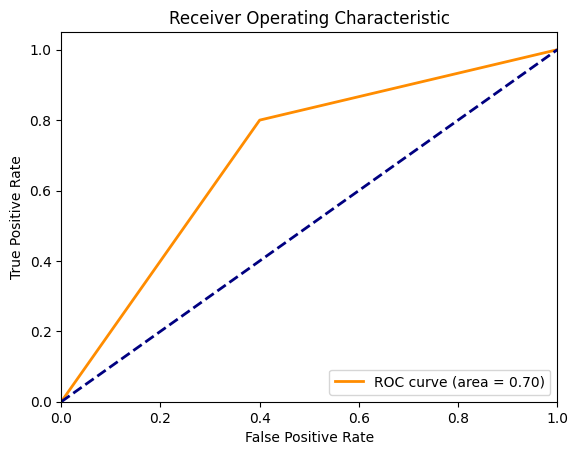

In [ ]:
# Plot ROC curve
plt.figure()

# Plot the ROC curve with a label displaying the ROC AUC score
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (area = {roc_auc:0.2f})' % roc_auc)

# Plot a dashed diagonal line for reference
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Set the x and y-axis limits
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Label the x and y-axes
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

# Set the title of the plot
plt.title('Receiver Operating Characteristic')

# Add a legend to the plot
plt.legend(loc='lower right');

### Ejemplo de métricas de clasificación usando un set de datos

In [ ]:
(train_X, train_y), (test_X, test_y) = mnist.load_data()
train_X = train_X.reshape((train_X.shape[0], 28, 28, 1)).astype('float32') / 255
test_X = test_X.reshape((test_X.shape[0], 28, 28, 1)).astype('float32') / 255
train_y = to_categorical(train_y)
test_y = to_categorical(test_y)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_X, train_y, epochs=3, batch_size=200, validation_split=0.2, verbose=2)
y_pred = model.predict(test_X)
y_pred_classes = y_pred.argmax(axis=1)
y_test_classes = test_y.argmax(axis=1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
240/240 - 25s - 106ms/step - accuracy: 0.9119 - loss: 0.3113 - val_accuracy: 0.9703 - val_loss: 0.1127
Epoch 2/3
240/240 - 21s - 89ms/step - accuracy: 0.9732 - loss: 0.0924 - val_accuracy: 0.9772 - val_loss: 0.0812
Epoch 3/3
240/240 - 41s - 169ms/step - accuracy: 0.9830 - loss: 0.0597 - val_accuracy: 0.9829 - val_loss: 0.0610
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


In [ ]:
accuracy = accuracy_score(y_test_classes, y_pred_classes)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.9828


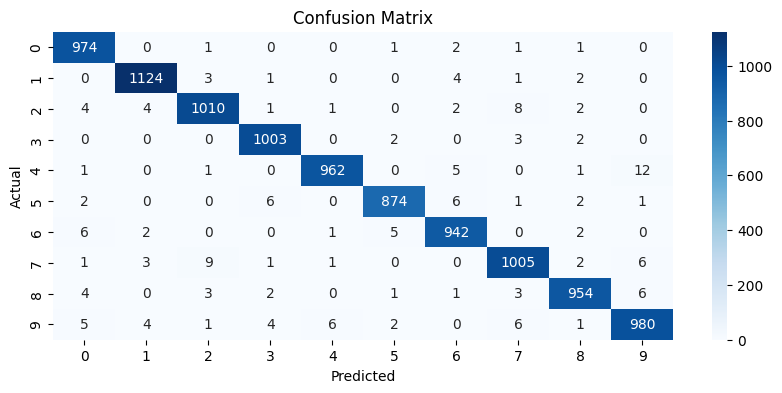

In [ ]:
cm = confusion_matrix(y_test_classes, y_pred_classes)
plt.figure(figsize=(10, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
print(classification_report(y_test_classes, y_pred_classes))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.98      0.99       982
           5       0.99      0.98      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [ ]:
precision = precision_score(y_test_classes, y_pred_classes, average='macro')
recall = recall_score(y_test_classes, y_pred_classes, average='macro')
f1 = f1_score(y_test_classes, y_pred_classes, average='macro')

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

Precision: 0.9828
Recall: 0.9827
F1 Score: 0.9827


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
ROC AUC: 0.9998


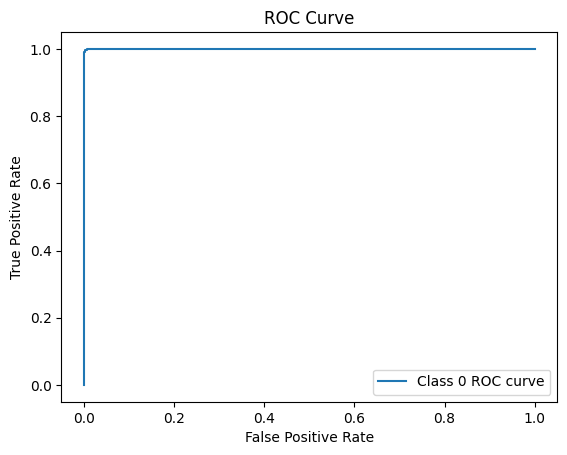

In [ ]:
# Assuming y_test and y_pred_prob are the true labels and predicted probabilities respectively
y_pred_prob = model.predict(test_X)
roc_auc = roc_auc_score(test_y, y_pred_prob, multi_class='ovr')

print(f'ROC AUC: {roc_auc:.4f}')

# Plotting ROC Curve for one class (e.g., class 0)
fpr, tpr, _ = roc_curve(y_test_classes == 0, y_pred_prob[:, 0])
plt.plot(fpr, tpr, label='Class 0 ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

# Underfitting y Overfitting

Un buen modelo no solamente debe funcionar bien sobre la data de entrenamiento sino también sobre nueva data que no haya visto previamente. Es por esto que para un buen modelo se espera que:

- Entiende los patrones de la data de entrenamiento.
- Generaliza bien sobre nueva data.
- Evita memorizar los errores de la data de entrenamiento (overfitting) o no capturar patrones importantes (underfitting).

Para evaluar qué tan bien generaliza un modelo, no solo se evalua sobre la data de entrenamiento sino también sobre data de validación y/o test.

## Overfitting y underfitting en problemas de regresión

![alt text](https://media.geeksforgeeks.org/wp-content/uploads/20230829151403/Bias-and-Variance-in-Machine-Learning.webp)

Fuente: https://www.geeksforgeeks.org/machine-learning/underfitting-and-overfitting-in-machine-learning/

## Overfitting y underfitting en problemas de clasificación

![alt text](https://media.geeksforgeeks.org/wp-content/cdn-uploads/20190523171258/overfitting_2.png)

Fuente: Ibid

## El balance entre Bias y Varianza

La relación entre bias y varianza suele llamarse el *'bias-variance tradeoff'*, para el cual se tiene que:

- Al aumentar la complejidad del modelo se reduce el bias con el riesgo de generar overfitting.

- Al simplificar el modelo se reduce la varianza con el riesgo de generar underfitting.

Al final la meta es encontrar el balance entre bias y varianza con el fin de encontrar el modelo óptimo.

## ¿Cómo atacar el Overfitting y Underfitting?

### Reducir Underfitting
- Incrementar la complejidad del modelo.
- Aumentar el número de variables, por ejemplo, incluyendo nuevas columnas o haciendo feature engineering.
- Quitar ruido en los datos (data cleaning).
- Aumentar las épocas de entrenamiento.

### Reducir Overfitting

- Aumentar la data entrenamiento.
- Reducir la complejidad del modelo.
- Hacer un *'early stopping'*.
- Aplicar regularización sobre los datos.
  - Ridge: $loss = MSE + \lambda \sum_{i=1}^n w_i^2$
  - Lasso: $loss = MSE + \lambda \sum_{i=1}^n |w_i|$
- En redes neuronales aplicar dropout.
Ridge Regularization and Lasso Regularization.
Use dropout for neural networks to tackle overfitting.